# Bert Notebook 1/3: Frozen BERT Embeddings + Classical Models (LogReg, XGBoost)

This is the first part of the split project. The split was done to fit comfortably within the limits of a free Colab
session:

1. **Notebook 1 (this one)** — frozen BERT: embedding extraction + LogReg/XGBoost on top of it.
2. **Notebook 2** — partial fine-tuning (frozen base, unfrozen pooler).
3. **Notebook 3** — full fine-tuning (all weights unfrozen) — the heaviest and longest stage.

## Google Drive: mounting and paths

Here we define a single folder structure on Drive that will be shared by all three notebooks:

- `DATA_DIR` — input data (`train_features_full.csv`, `val_features_full.csv`,
  `test_features_full.csv`, `results_val.csv`, `results_train.csv`, `val_predictions.pkl`) —
  produced and saved back in the earlier stage (the TF-IDF/Word2Vec notebook).
- `ARTIFACTS_DIR` — where everything computed in this and the next notebooks is stored
  (BERT embeddings, updated metric tables, fine-tuning checkpoints).

In [ ]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

import os

PROJECT_ROOT = '/content/drive/MyDrive/quora_dup_detection'
DATA_DIR = os.path.join(PROJECT_ROOT, 'data')
ARTIFACTS_DIR = os.path.join(PROJECT_ROOT, 'artifacts')

print('DATA_DIR:     ', DATA_DIR)
print('ARTIFACTS_DIR:', ARTIFACTS_DIR)
print('DATA_DIR contents:', os.listdir(DATA_DIR))

Mounted at /content/drive
DATA_DIR:      /content/drive/MyDrive/quora_dup_detection/data
ARTIFACTS_DIR: /content/drive/MyDrive/quora_dup_detection/artifacts
DATA_DIR contents: ['results_test.csv', 'results_train.csv', 'results_val.csv', 'quora_question_pairs_test.csv', 'val_predictions.pkl', 'val_features_full.csv', 'quora_question_pairs_train.csv', 'train_features_full.csv', 'test_features_full.csv']


## Imports and GPU check

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import gc
import pickle
warnings.filterwarnings('ignore')

import torch
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import log_loss, accuracy_score, f1_score, confusion_matrix, roc_auc_score
import xgboost as xgb

from transformers import BertTokenizer, BertModel

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
if device.type == 'cpu':
    print('WARNING: no GPU detected! Runtime -> Change runtime type -> GPU.')
else:
    # useful to know exactly which GPU we got (T4 / A100 / L4) - affects batch_size below
    print(torch.cuda.get_device_name(0))

Device: cuda
Tesla T4


## Loading data from Google Drive

In [ ]:
train_df = pd.read_csv(os.path.join(DATA_DIR, 'train_features_full.csv'))
val_df = pd.read_csv(os.path.join(DATA_DIR, 'val_features_full.csv'))
test_df = pd.read_csv(os.path.join(DATA_DIR, 'test_features_full.csv'))

engineered_features = ['common_word_count', 'union_word_count', 'word_share_jaccard',
                        'common_over_min_len', 'common_over_max_len', 'token_len_diff', 'char_len_diff']
tfidf_sim_cols = ['tfidf_cosine', 'tfidf_euclidean', 'tfidf_manhattan']
w2v_sim_cols = ['w2v_avg_cosine', 'w2v_avg_euclidean', 'w2v_avg_manhattan',
                'w2v_weighted_cosine', 'w2v_weighted_euclidean', 'w2v_weighted_manhattan']

print('Train shape:', train_df.shape)
print('Val shape:  ', val_df.shape)
print('Test shape: ', test_df.shape)

y_train = train_df['is_duplicate'].values
y_val = val_df['is_duplicate'].values
y_test = test_df['is_duplicate'].values

Train shape: (266488, 22)
Val shape:   (56941, 22)
Test shape:  (80858, 22)


In [ ]:
# Results from previous models (TF-IDF / Word2Vec) - also loaded from Drive
val_results_prev = pd.read_csv(os.path.join(DATA_DIR, 'results_val.csv'))
train_results_prev = pd.read_csv(os.path.join(DATA_DIR, 'results_train.csv'))

with open(os.path.join(DATA_DIR, 'val_predictions.pkl'), 'rb') as f:
    val_predictions = pickle.load(f)

print('='*30+'Train'+'='*30)
display(train_results_prev)

print('='*30+'Validation'+'='*30)
display(val_results_prev)

==============================Train==============================


,model,log_loss,f1,accuracy,roc_auc
0,Naive constant baseline,0.655518,0.000000,0.636299,0.500000
1,Threshold on word_share_jaccard,0.648484,0.632415,0.625364,0.732250
2,Logistic Regression (TF-IDF + features),0.426158,0.697843,0.790347,0.873204
3,XGBoost (TF-IDF),0.448985,0.653174,0.774545,0.858775
4,Logistic Regression (Word2Vec),0.492585,0.623092,0.735035,0.815719
5,XGBoost (Word2Vec),0.360521,0.780661,0.842781,0.922449


==============================Validation==============================


,model,log_loss,f1,accuracy,roc_auc
0,Naive constant baseline,0.672988,0.000000,0.605065,0.500000
1,Threshold on word_share_jaccard,0.650177,0.655511,0.636659,0.722330
2,Logistic Regression (TF-IDF + features),0.525917,0.581317,0.711052,0.804393
3,XGBoost (TF-IDF),0.521324,0.523074,0.699988,0.797677
4,Logistic Regression (Word2Vec),0.531765,0.581234,0.700198,0.790394
5,XGBoost (Word2Vec),0.489078,0.630928,0.737992,0.829651


## Loading BERT (frozen, used only to extract embeddings)

In [ ]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased')
model.to(device)
model.eval()

print('Model loaded, hidden_size =', model.config.hidden_size)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded, hidden_size = 768


## Mean pooling function

Sentence embedding = mean of token embeddings, weighted by `attention_mask` (so padding tokens
don't affect the result) — generally gives better sentence-level representations than the raw
`[CLS]` vector for similarity tasks.


In [ ]:
def mean_pooling(token_embeddings, attention_mask):
    mask = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
    summed = torch.sum(token_embeddings * mask, dim=1)
    counts = torch.clamp(mask.sum(dim=1), min=1e-9)
    return summed / counts

@torch.no_grad()
def get_bert_embeddings(texts, tokenizer, model, device, batch_size=64, max_length=64):
    """Batched BERT embedding extraction with mean pooling.

    Writes directly into a preallocated float32 numpy array - storing one array per DataFrame
    row (object dtype column) is very memory-inefficient at this scale and previously caused an
    out-of-memory crash in an earlier phase of this project.
    """
    n = len(texts)
    hidden_size = model.config.hidden_size
    embeddings = np.zeros((n, hidden_size), dtype=np.float32)

    for start in range(0, n, batch_size):
        batch_texts = texts[start:start + batch_size]
        encoded = tokenizer(
            batch_texts, padding=True, truncation=True,
            max_length=max_length, return_tensors='pt'
        ).to(device)

        output = model(**encoded)
        token_embeddings = output.last_hidden_state
        pooled = mean_pooling(token_embeddings, encoded['attention_mask'])

        embeddings[start:start + len(batch_texts)] = pooled.cpu().numpy()

        if start % (batch_size * 50) == 0:
            print(f'  {start}/{n} processed...')

    return embeddings

## Extracting BERT embeddings for train / val / test

In [ ]:
%%time
q1_train_path = os.path.join(ARTIFACTS_DIR, 'q1_bert_train.npy')
q2_train_path = os.path.join(ARTIFACTS_DIR, 'q2_bert_train.npy')

# If the files already exist on Drive (e.g. after a disconnected session) - don't recompute
if os.path.exists(q1_train_path) and os.path.exists(q2_train_path):
    print('Found existing train embeddings on Drive, loading instead of recomputing.')
    q1_bert_train = np.load(q1_train_path)
    q2_bert_train = np.load(q2_train_path)
else:
    q1_bert_train = get_bert_embeddings(train_df['question1'].tolist(), tokenizer, model, device)
    q2_bert_train = get_bert_embeddings(train_df['question2'].tolist(), tokenizer, model, device)
    np.save(q1_train_path, q1_bert_train)
    np.save(q2_train_path, q2_bert_train)
    print('Train embeddings saved to Drive.')

Found existing train embeddings on Drive, loading instead of recomputing.
CPU times: user 3.67 ms, sys: 1.76 s, total: 1.76 s
Wall time: 29.4 s


In [ ]:
%%time
q1_val_path = os.path.join(ARTIFACTS_DIR, 'q1_bert_val.npy')
q2_val_path = os.path.join(ARTIFACTS_DIR, 'q2_bert_val.npy')

if os.path.exists(q1_val_path) and os.path.exists(q2_val_path):
    print('Found existing val embeddings on Drive, loading instead of recomputing.')
    q1_bert_val = np.load(q1_val_path)
    q2_bert_val = np.load(q2_val_path)
else:
    q1_bert_val = get_bert_embeddings(val_df['question1'].tolist(), tokenizer, model, device)
    q2_bert_val = get_bert_embeddings(val_df['question2'].tolist(), tokenizer, model, device)
    np.save(q1_val_path, q1_bert_val)
    np.save(q2_val_path, q2_bert_val)
    print('Val embeddings saved to Drive.')

Found existing val embeddings on Drive, loading instead of recomputing.
CPU times: user 41 ms, sys: 328 ms, total: 369 ms
Wall time: 15.2 s


In [ ]:
%%time
q1_test_path = os.path.join(ARTIFACTS_DIR, 'q1_bert_test.npy')
q2_test_path = os.path.join(ARTIFACTS_DIR, 'q2_bert_test.npy')

if os.path.exists(q1_test_path) and os.path.exists(q2_test_path):
    print('Found existing test embeddings on Drive, loading instead of recomputing.')
    q1_bert_test = np.load(q1_test_path)
    q2_bert_test = np.load(q2_test_path)
else:
    q1_bert_test = get_bert_embeddings(test_df['question1'].tolist(), tokenizer, model, device)
    q2_bert_test = get_bert_embeddings(test_df['question2'].tolist(), tokenizer, model, device)
    np.save(q1_test_path, q1_bert_test)
    np.save(q2_test_path, q2_bert_test)
    print('Test embeddings saved to Drive.')

# The model is no longer needed - free GPU memory before training the classical ML models
del model, tokenizer
gc.collect()
torch.cuda.empty_cache()

Found existing test embeddings on Drive, loading instead of recomputing.
CPU times: user 218 ms, sys: 753 ms, total: 970 ms
Wall time: 17.4 s


## BERT similarity features (cosine / euclidean / manhattan)

In [ ]:
def compute_dense_similarity(A, B):
    dot = np.sum(A * B, axis=1)
    norm_a = np.linalg.norm(A, axis=1)
    norm_b = np.linalg.norm(B, axis=1)
    denom = norm_a * norm_b
    cosine_sim = np.divide(dot, denom, out=np.zeros_like(dot), where=denom != 0)
    euclidean = np.linalg.norm(A - B, axis=1)
    manhattan = np.sum(np.abs(A - B), axis=1)
    return cosine_sim, euclidean, manhattan

bert_sim_cols = ['bert_cosine', 'bert_euclidean', 'bert_manhattan']

for df, q1_emb, q2_emb in [(train_df, q1_bert_train, q2_bert_train),
                           (val_df, q1_bert_val, q2_bert_val),
                           (test_df, q1_bert_test, q2_bert_test)]:
    cos, eucl, manh = compute_dense_similarity(q1_emb, q2_emb)
    df['bert_cosine'] = cos
    df['bert_euclidean'] = eucl
    df['bert_manhattan'] = manh

print('Correlation with is_duplicate (train):')
train_df[bert_sim_cols + ['is_duplicate']].corr()['is_duplicate']

Correlation with is_duplicate (train):


,is_duplicate
bert_cosine,0.400566
bert_euclidean,-0.384724
bert_manhattan,-0.385116
is_duplicate,1.000000


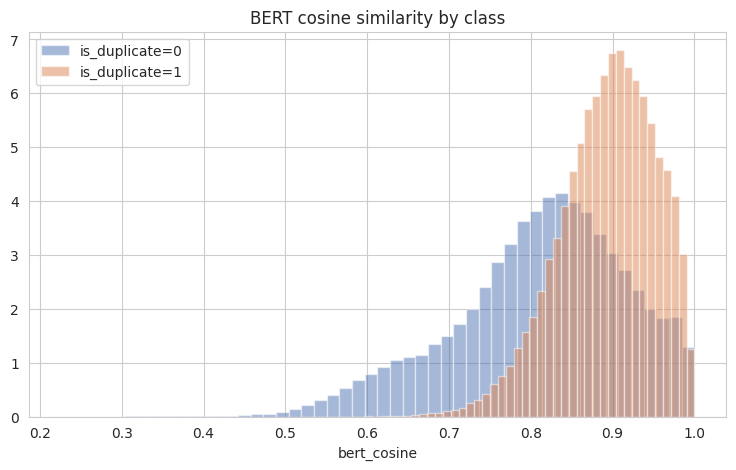

In [ ]:
plt.figure(figsize=(9, 5))
for label, color in zip([0, 1], ['#4C72B0', '#DD8452']):
    subset = train_df[train_df.is_duplicate == label]
    plt.hist(subset['bert_cosine'], bins=50, alpha=0.5, label=f'is_duplicate={label}', color=color, density=True)
plt.title('BERT cosine similarity by class')
plt.xlabel('bert_cosine')
plt.legend()
plt.show()

## Building the final feature matrix: BERT vectors + all previous features

In [ ]:
all_extra_cols = engineered_features + tfidf_sim_cols + w2v_sim_cols + bert_sim_cols

scaler = StandardScaler()
extra_train_scaled = scaler.fit_transform(train_df[all_extra_cols])
extra_val_scaled = scaler.transform(val_df[all_extra_cols])
extra_test_scaled = scaler.transform(test_df[all_extra_cols])

X_train_bert = np.hstack([q1_bert_train, q2_bert_train, extra_train_scaled])
X_val_bert = np.hstack([q1_bert_val, q2_bert_val, extra_val_scaled])
X_test_bert = np.hstack([q1_bert_test, q2_bert_test, extra_test_scaled])

print('X_train_bert shape:', X_train_bert.shape)
print('X_val_bert shape:  ', X_val_bert.shape)
print('X_test_bert shape: ', X_test_bert.shape)

#np.save(os.path.join(ARTIFACTS_DIR, 'X_train_bert.npy'), X_train_bert)
#np.save(os.path.join(ARTIFACTS_DIR, 'X_val_bert.npy'), X_val_bert)
#np.save(os.path.join(ARTIFACTS_DIR, 'X_test_bert.npy'), X_test_bert)
#print('Feature matrices saved to Drive.')

X_train_bert shape: (266488, 1555)
X_val_bert shape:   (56941, 1555)
X_test_bert shape:  (80858, 1555)


## Model 1: Logistic Regression on BERT features

In [ ]:
%%time
logreg_bert = LogisticRegression(max_iter=500, random_state=42)
logreg_bert.fit(X_train_bert, y_train)

CPU times: user 4min 22s, sys: 261 ms, total: 4min 23s
Wall time: 2min 40s


LogisticRegression(max_iter=500, random_state=42)

In [ ]:
def add_result(results, model_name, y_true, y_proba, threshold=0.5):
    y_pred = (y_proba >= threshold).astype(int)

    row = {
        'model': model_name,
        'log_loss': log_loss(y_true, y_proba),
        'f1': f1_score(y_true, y_pred),
        'accuracy': accuracy_score(y_true, y_pred),
        'roc_auc': roc_auc_score(y_true, y_proba)
    }

    results.loc[len(results)] = row
    display(results)

    return results

In [ ]:
train_proba_lr_bert = logreg_bert.predict_proba(X_train_bert)[:, 1]
train_preds_lr_bert = (train_proba_lr_bert >= 0.5).astype(int)

val_proba_lr_bert = logreg_bert.predict_proba(X_val_bert)[:, 1]
val_preds_lr_bert = (val_proba_lr_bert >= 0.5).astype(int)


In [ ]:
print('='*30+'Train'+'='*30)
train_results = add_result(
    train_results_prev,
    'Logistic Regression (BERT, frozen)',
    y_train,
    train_proba_lr_bert
)

print('='*30+'Validation'+'='*30)
val_results = add_result(
    val_results_prev,
    'Logistic Regression (BERT, frozen)',
    y_val,
    val_proba_lr_bert
)

==============================Train==============================


,model,log_loss,f1,accuracy,roc_auc
0,Naive constant baseline,0.655518,0.000000,0.636299,0.500000
1,Threshold on word_share_jaccard,0.648484,0.632415,0.625364,0.732250
2,Logistic Regression (TF-IDF + features),0.426158,0.697843,0.790347,0.873204
3,XGBoost (TF-IDF),0.448985,0.653174,0.774545,0.858775
4,Logistic Regression (Word2Vec),0.492585,0.623092,0.735035,0.815719
5,XGBoost (Word2Vec),0.360521,0.780661,0.842781,0.922449
6,"Logistic Regression (BERT, frozen)",0.425666,0.705789,0.789011,0.870666


==============================Validation==============================


,model,log_loss,f1,accuracy,roc_auc
0,Naive constant baseline,0.672988,0.000000,0.605065,0.500000
1,Threshold on word_share_jaccard,0.650177,0.655511,0.636659,0.722330
2,Logistic Regression (TF-IDF + features),0.525917,0.581317,0.711052,0.804393
3,XGBoost (TF-IDF),0.521324,0.523074,0.699988,0.797677
4,Logistic Regression (Word2Vec),0.531765,0.581234,0.700198,0.790394
5,XGBoost (Word2Vec),0.489078,0.630928,0.737992,0.829651
6,"Logistic Regression (BERT, frozen)",0.502090,0.636392,0.738027,0.826067


## Model 2: XGBoost on BERT features

In [ ]:
%%time
xgb_bert = xgb.XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    tree_method='hist', eval_metric='logloss', random_state=42
)
xgb_bert.fit(X_train_bert, y_train)

CPU times: user 14min 12s, sys: 2.18 s, total: 14min 15s
Wall time: 14min 28s


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
train_proba_xgb_bert = xgb_bert.predict_proba(X_train_bert)[:, 1]
train_preds_xgb_bert = (train_proba_xgb_bert >= 0.5).astype(int)

val_proba_xgb_bert = xgb_bert.predict_proba(X_val_bert)[:, 1]
val_preds_xgb_bert = (val_proba_xgb_bert >= 0.5).astype(int)

In [ ]:
print('='*30+'Train'+'='*30)
train_results = add_result(
    train_results_prev,
    'XGBoost (BERT, frozen)',
    y_train,
    train_proba_xgb_bert
)

print('='*30+'Validation'+'='*30)
val_results = add_result(
    val_results_prev,
    'XGBoost (BERT, frozen)',
    y_val,
    val_proba_xgb_bert
)

==============================Train==============================


,model,log_loss,f1,accuracy,roc_auc
0,Naive constant baseline,0.655518,0.000000,0.636299,0.500000
1,Threshold on word_share_jaccard,0.648484,0.632415,0.625364,0.732250
2,Logistic Regression (TF-IDF + features),0.426158,0.697843,0.790347,0.873204
3,XGBoost (TF-IDF),0.448985,0.653174,0.774545,0.858775
4,Logistic Regression (Word2Vec),0.492585,0.623092,0.735035,0.815719
5,XGBoost (Word2Vec),0.360521,0.780661,0.842781,0.922449
6,"Logistic Regression (BERT, frozen)",0.425666,0.705789,0.789011,0.870666
7,"XGBoost (BERT, frozen)",0.325103,0.808335,0.860969,0.938558


==============================Validation==============================


,model,log_loss,f1,accuracy,roc_auc
0,Naive constant baseline,0.672988,0.000000,0.605065,0.500000
1,Threshold on word_share_jaccard,0.650177,0.655511,0.636659,0.722330
2,Logistic Regression (TF-IDF + features),0.525917,0.581317,0.711052,0.804393
3,XGBoost (TF-IDF),0.521324,0.523074,0.699988,0.797677
4,Logistic Regression (Word2Vec),0.531765,0.581234,0.700198,0.790394
5,XGBoost (Word2Vec),0.489078,0.630928,0.737992,0.829651
6,"Logistic Regression (BERT, frozen)",0.502090,0.636392,0.738027,0.826067
7,"XGBoost (BERT, frozen)",0.464834,0.669767,0.761806,0.852425


**Conclusion:** XGBoost with frozen BERT achieved the best performance in the entire project. It reduced the log loss from 0.489 (Word2Vec) to 0.465, representing an improvement of approximately 3.5%, and achieved the highest F1 score, accuracy, and ROC-AUC among all evaluated approaches.

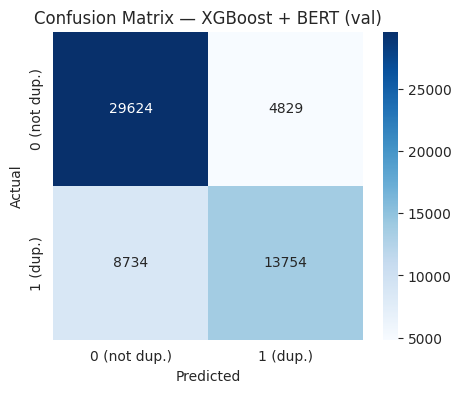

In [ ]:
cm_bert = confusion_matrix(y_val, val_preds_xgb_bert)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_bert, annot=True, fmt='d', cmap='Blues',
            xticklabels=['0 (not dup.)', '1 (dup.)'], yticklabels=['0 (not dup.)', '1 (dup.)'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — XGBoost + BERT (val)')
plt.show()

## Final test evaluation (best model only) + leakage check

We evaluate only the single best model (by val log loss) on `test.csv`.

In [ ]:
best_row = val_results.loc[val_results['log_loss'].idxmin()]
print(f"Best model by val log loss: {best_row['model']} (log_loss={best_row['log_loss']:.4f})")

if 'BERT' in best_row['model']:
    best_model_obj = xgb_bert if 'XGBoost' in best_row['model'] else logreg_bert
    test_proba = best_model_obj.predict_proba(X_test_bert)[:, 1]
else:
    print('Best model is not BERT-based - evaluate it on test using its own X_test matrix '
          'from the previous notebook (X_test_tfidf / X_test_w2v).')
    test_proba = None

if test_proba is not None:
    test_preds = (test_proba >= 0.5).astype(int)
    print(f'Test log loss: {log_loss(y_test, test_proba):.4f}')
    print(f'Test F1: {f1_score(y_test, test_preds):.4f}')
    print(f'Test accuracy: {accuracy_score(y_test, test_preds):.4f}')
    print(f'Test ROC-AUC: {roc_auc_score(y_test, test_proba):.4f}')

Best model by val log loss: XGBoost (BERT, frozen) (log_loss=0.4648)
Test log loss: 0.3904
Test F1: 0.7383
Test accuracy: 0.8107
Test ROC-AUC: 0.8947


**Conclusion:** the final evaluation on the test set confirms that the model generalizes well to previously unseen data. XGBoost trained on frozen BERT embeddings achieved the best overall performance, obtaining the lowest log loss and the highest F1 score, accuracy, and ROC-AUC among all evaluated approaches.

These results demonstrate that contextual BERT embeddings provide more informative semantic representations than TF-IDF and Word2Vec features, while the XGBoost classifier effectively exploits these representations. Overall, the proposed approach offers the best trade-off between predictive performance and computational efficiency, as it benefits from pretrained contextual embeddings without requiring expensive BERT fine-tuning.

## Saving updated metric tables to Drive

In [ ]:
train_results.to_csv(os.path.join(DATA_DIR, 'results_train_p2.csv'), index=False)
val_results.to_csv(os.path.join(DATA_DIR, 'results_val_p2.csv'), index=False)
print('Saved results_train_p2.csv / results_val_p2.csv saved to Drive.')

Saved results_train_p2.csv / results_val_p2.csv saved to Drive.


## 12. Error analysis (best model in this notebook — XGBoost + BERT, val split)

Let's look at examples where the model got it wrong, to understand the nature of the errors
(false negative — missed duplicates, false positive — pairs wrongly flagged as duplicates).


In [ ]:
error_df = val_df[['question1', 'question2']].copy()
error_df['is_duplicate'] = y_val
error_df['pred_proba'] = val_proba_xgb_bert
error_df['pred_label'] = val_preds_xgb_bert

conditions = [
    (error_df['is_duplicate'] == 1) & (error_df['pred_label'] == 1),
    (error_df['is_duplicate'] == 0) & (error_df['pred_label'] == 0),
    (error_df['is_duplicate'] == 1) & (error_df['pred_label'] == 0),
    (error_df['is_duplicate'] == 0) & (error_df['pred_label'] == 1),
]
choices = ['true_positive', 'true_negative', 'false_negative', 'false_positive']
error_df['error_type'] = np.select(conditions, choices, default='unknown')

print(error_df['error_type'].value_counts())

error_type
true_negative     29624
true_positive     13754
false_negative     8734
false_positive     4829
Name: count, dtype: int64


In [ ]:
print('Examples of FALSE NEGATIVE (actual duplicate that the model missed):')
error_df[error_df.error_type == 'false_negative'][['question1', 'question2', 'pred_proba']].sample(
    min(10, (error_df.error_type == 'false_negative').sum()), random_state=1
)

Examples of FALSE NEGATIVE (actual duplicate that the model missed):


,question1,question2,pred_proba
35639,How can I have a big penis?,How do I enlarge the length and width of my pe...,0.119741
51442,How should I reduce my belly naturally?,How can I reduce my Belly and tummy fat?,0.458296
22592,What are the Major problems in Indian educatio...,What is wrong with the Indian education system?,0.455034
34305,Who is the cursed child in the Harry Potter an...,Who actually is the cursed child?,0.108710
37952,How do you log in to Facebook if you forgot yo...,Is it possible to login to Facebook without pa...,0.273782
11010,How do I get job in Bangalore for mechanical e...,What are job opportunities for mechanical engi...,0.236019
23743,How do i lose weight?,How can I lose an extreme amount of weight?,0.481455
39337,How is TCS for fresher?,TCS for freshers?,0.412860
34083,What should one do in order to escape boredom?,How did you beat boredom?,0.398517
47253,How can I lose 20 pounds in one month?,Is it possible to lose 20 pounds in a month?,0.426186


In [ ]:
print('Examples of FALSE POSITIVE (predicted duplicate, but actually not):')
error_df[error_df.error_type == 'false_positive'][['question1', 'question2', 'pred_proba']].sample(
    min(10, (error_df.error_type == 'false_positive').sum()), random_state=1
)

Examples of FALSE POSITIVE (predicted duplicate, but actually not):


,question1,question2,pred_proba
25388,Is Canada's healthcare system a national progr...,Is the U.K. healthcare system a national progr...,0.597973
12034,Who is the best actor in world?,Who is the greatest movie actor in the world a...,0.588966
5301,What is a good skill that I can learn that I c...,Is it possible to make a career out of learning?,0.703874
51851,What are the perks of having you as girlfriend?,What are the perks of having a girlfriend?,0.840874
7102,Is Quora banned in China as of 8 December 2016?,Is Quora banned in China?,0.551934
17785,How do I make money with no money?,How do I make money with Pokémon?,0.639531
33257,Who will win; lizard or rat?,Who will win: lizard or frog?,0.677345
33680,Why should I learn Romanian?,Where can I learn Romanian?,0.530951
33471,Are Scandinavian countries socialist?,How socialist are Scandinavian countries?,0.722941
7687,How do pandas eat bamboo?,Why do pandas eat bamboo?,0.742353


**Conclusion:** False negatives cluster around two causes: near-threshold uncertainty (recoverable by threshold tuning) and dropped shared context/entities between paraphrased questions, which frozen embeddings fail to reconcile. This motivates moving to fine-tuned BERT models in the following notebooks, which can learn context-aware similarity rather than relying on static pooled representations.